In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
trace_num = 2000
order = '0'
opt = 'o3' # o0 or o3
scope = '' # _chipwhisperer or space
algo = 'PQClean' # orgPoly or PQClean or pqm4
platform = 'CW308_STM32F4' # CW308_STM32F3 or CW308_STM32F4 or CWLITEARM

trace_path = f'traces{scope}/{trace_num}/traces_unfixed_message_{trace_num}_{platform}_{opt}_{algo}_{order}'


t = np.load(f'{trace_path}/trace.npy')
m = np.load(f'{trace_path}/message.npy')

In [3]:
print(t.shape)
print(m.shape)
print(m)

(2000, 455000)
(2000, 32)
[[244.  93.  77. ... 130.  86.  78.]
 [109. 212. 171. ... 238. 173.  36.]
 [ 67. 179.  54. ...  59. 252.  36.]
 ...
 [ 91. 144. 225. ...  65.  47.  20.]
 [209. 210. 192. ... 224.  81. 122.]
 [234.  88.   7. ...  46. 150. 201.]]


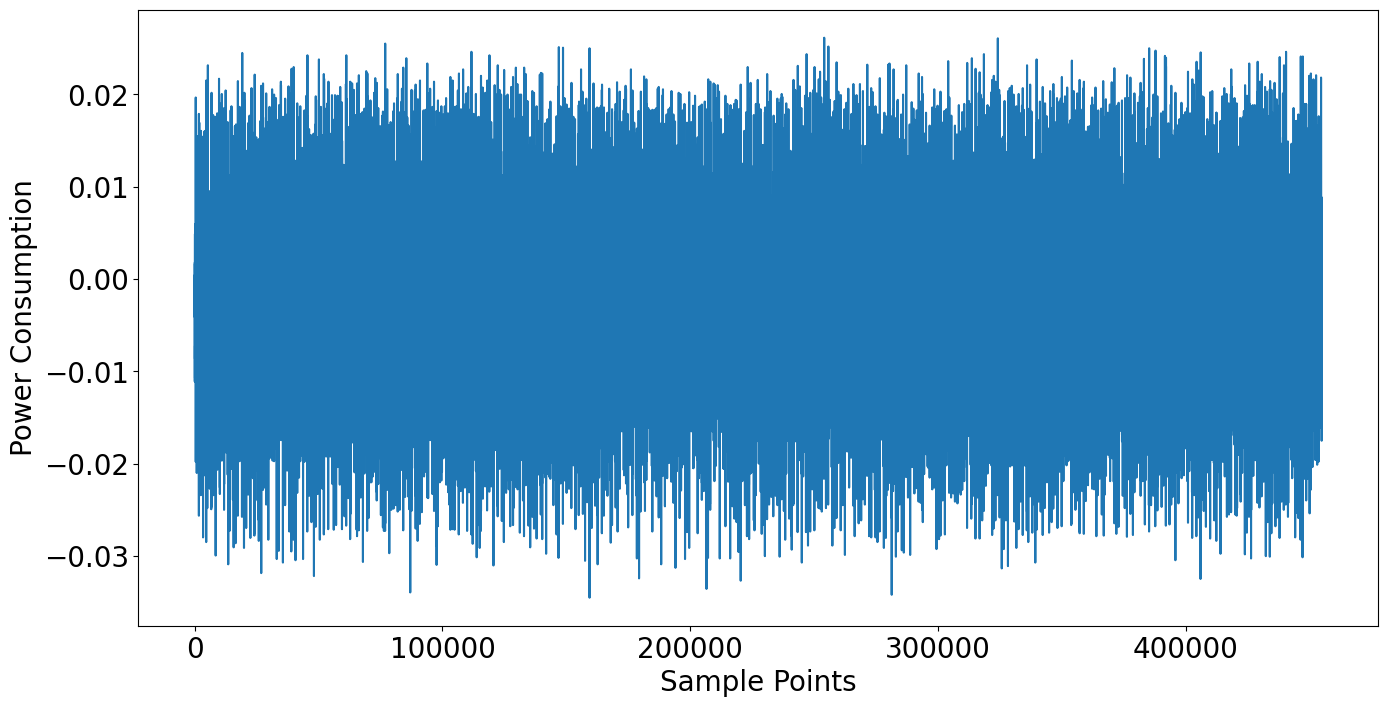

In [4]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
plt.plot(t[0])
# plt.savefig('figure/load_trace/unfixed_message_2000_single_trace.png', dpi=200, bbox_inches='tight')

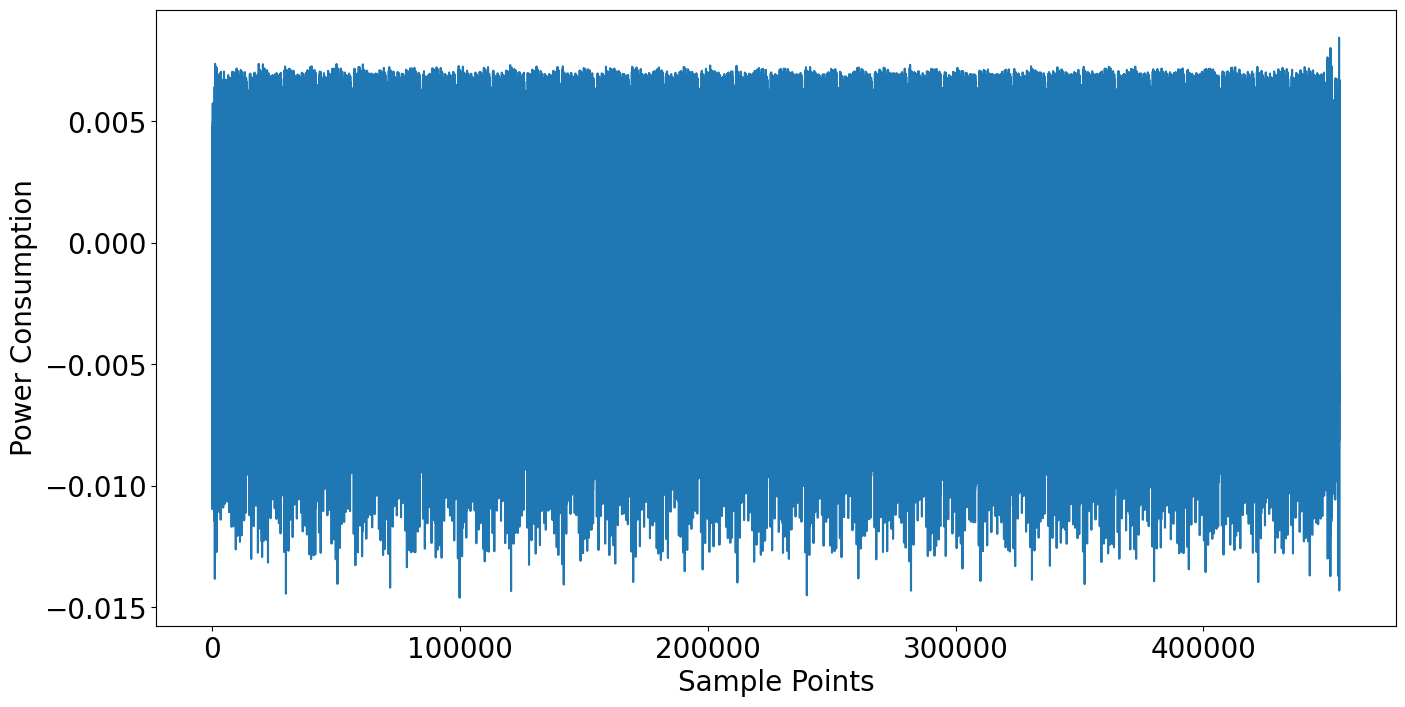

In [5]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
plt.plot(np.mean(t, axis=0))
# plt.savefig('figure/load_trace/unfixed_message_2000_mean_trace.png', dpi=200, bbox_inches='tight')

In [22]:
import numpy as np
from scipy.signal import firwin, filtfilt, lfilter

# 假設你在 FFT 裡看到 7.37MHz 諧波洩漏，
# 取樣率 fs = 500e6，想做一個窄帶帶阻
fs = 500e6
notch_freq = 7.37e6
bw = 0.5e6       # 帶阻寬度 0.5MHz
# 設計 FIR 帶阻：用兩個低通 + 高通差分實現
numtaps = 101    # 階數可微調
# 先做一個低通 bp1，截止於 notch_freq - bw/2
lp = firwin(numtaps, cutoff=notch_freq - bw/2, fs=fs)
# 再做一個低通 bp2，截止於 notch_freq + bw/2
bp = firwin(numtaps, cutoff=notch_freq + bw/2, fs=fs)
# 帶阻濾波器 = lp - bp
notch = lp - bp

# 再加一個梳狀濾波器 (Comb)
# delay N = fs / notch_freq  -> 在 notch_freq 處有零點
N = int(round(fs / notch_freq))
# Comb 輸入 x -> y[n] = x[n] - x[n-N]
def comb_filter(x, N):
    y = np.zeros_like(x)
    y[:N] = x[:N]
    y[N:] = x[N:] - x[:-N]
    return y

# 假設 t 是 (num_traces, trace_len) 的原始功率軌跡陣列
filtered = np.zeros_like(t)
for i in range(t.shape[0]):
    # 先梳狀濾波去時脈諧波
    c = comb_filter(t[i], N)
    # 再用窄帶帶阻去除剩餘洩漏尖峰
    filtered[i] = filtfilt(notch, 1, c)

# 這樣就同時去除了主時脈諧波和附近的窄頻洩漏



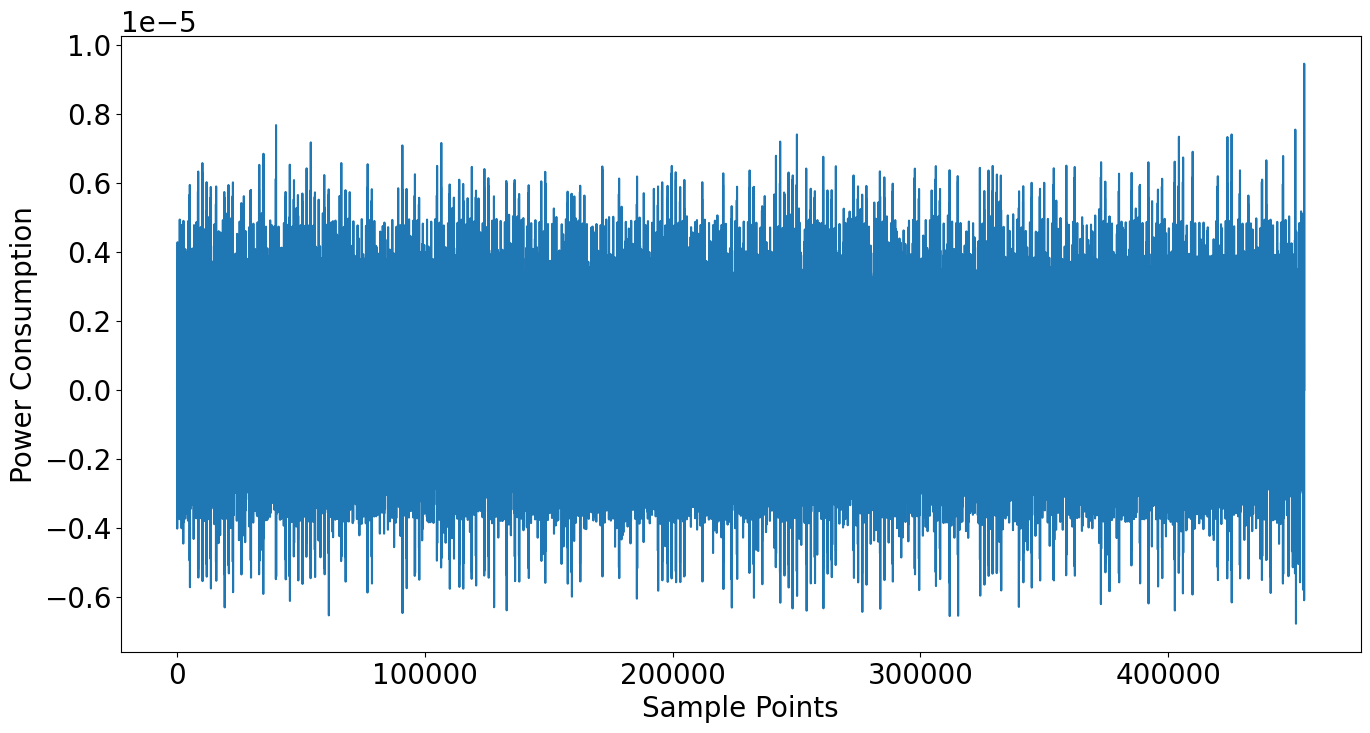

In [23]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
plt.plot(filtered[0])
# plt.savefig('figure/load_trace/unfixed_message_2000_single_trace.png', dpi=200, bbox_inches='tight')